In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [3]:
# 1. IPCC SSP SCENARIOS
# SSP1-2.6: Low warming (~1.8°C by 2100)
# SSP2-4.5: Middle of the road (~2.7°C by 2100)
# SSP5-8.5: High emissions (~4.4°C by 2100)

scenarios = {
    "SSP1-2.6 (Sustainable)": {"rate": 0.015, "limit": 1.8},
    "SSP2-4.5 (Middle)":      {"rate": 0.025, "limit": 3.0},
    "SSP5-8.5 (High-Risk)":   {"rate": 0.050, "limit": 5.0}
}

In [4]:
def get_ipcc_temp(t, rate, limit):
    "Returns Delta T at time t based on scenario parameters."
    # Temperatures rise and then stabilize/slowly increase after 2100 (t=100)
    return min(rate * t, limit)

In [5]:
# 2. THE PHYSICS MODEL
def ice_model(t, h, rate, limit):
    h = h[0]
    if h <= 0: return [0]

    # 1. Get global temperature anomaly for this year
    delta_T_global = get_ipcc_temp(t, rate, limit)

    # 2. Local Temperature + Lapse Rate Effect (The Tipping Mechanism)
    # T_surf = T_base + Delta_T_Global - (Lapse_Rate * Elevation_Loss)
    # As height 'h' decreases, surface temperature increases.
    lapse_rate = 0.006 # 6°C per 1000m height
    h_initial = 3000
    local_temp = -5 + delta_T_global + lapse_rate * (h_initial - h)

    # 3. Mass Balance
    precipitation = 0.91
    # Melting is highly sensitive to local temperature
    melting = 0.05 * max(0, local_temp)**2
    discharge = 0.001 * h # Ice flow rate into the ocean

    dh_dt = precipitation - melting - discharge
    return [dh_dt]

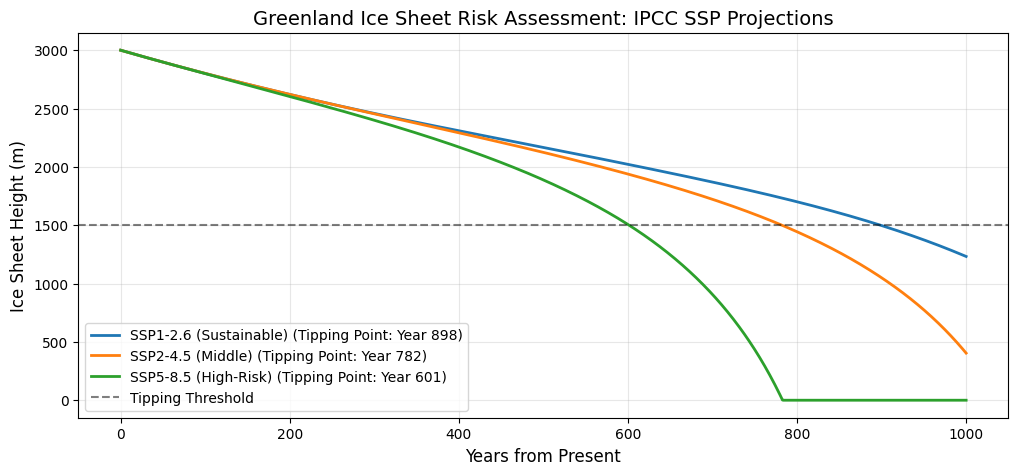

In [8]:
# 3. RUNNING THE RISK ASSESSMENT
time_span = [0, 1000] # 1000-year outlook
t_eval = np.linspace(0, 1000, 1000)
h0 = [3000]

plt.figure(figsize=(12, 5))

for name, params in scenarios.items():
    sol = solve_ivp(ice_model, time_span, h0,
                    args=(params["rate"], params["limit"]), t_eval=t_eval)

    # Identify Tipping Point (where height drops below 1500m)
    h_vals = sol.y[0]
    tipping_idx = np.where(h_vals < 1500)[0]
    tipping_year = sol.t[tipping_idx[0]] if len(tipping_idx) > 0 else None

    label = f"{name}"
    if tipping_year:
        label += f" (Tipping Point: Year {int(tipping_year)})"

    plt.plot(sol.t, h_vals, label=label, linewidth=2)

plt.axhline(y=1500, color='black', linestyle='--', alpha=0.5, label="Tipping Threshold")
plt.title("Greenland Ice Sheet Risk Assessment: IPCC SSP Projections", fontsize=14)
plt.xlabel("Years from Present", fontsize=12)
plt.ylabel("Ice Sheet Height (m)", fontsize=12)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()